# CWA Activation vs GELU/SELU/tanh-Swish in 6-Layer GPT Language Model

This notebook demonstrates the **Curie-Weiss Activation (CWA)** — a novel learned activation function whose output is the fixed point of `y = tanh(x + J·mean(y))`, where `J` is a trainable scalar coupling parameter.

**What this artifact does:**
- Defines CWA with a hybrid backward pass: unrolled autograd (when `J·s̄ < 0.8`) or implicit function theorem / IFT (when `J·s̄ ≥ 0.8`)
- Embeds CWA in the FFN blocks of a 6-layer, 256-hidden-dim, 8-head GPT model
- Compares CWA against GELU, GELU+LayerNorm, SELU, and tanh+Swish@0.5 on Tiny Shakespeare (char-level BPC) and WikiText-2 (BPE perplexity)
- Logs per-layer CWA diagnostics: coupling `J`, proximity to criticality `J·s̄`, fixed-point iteration count `K`, and backprop mode

**Full experiment**: 3 seeds × 500 steps on Shakespeare + 2 seeds × 500 steps on WikiText-2, ~20–25 min on GPU.  
**This demo**: Runs a tiny 2-layer GPT with 32-dim hidden for 20 steps using synthetic data (~30 seconds), then visualizes the pre-computed full results.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab — always install
_pip('loguru==0.7.3', 'psutil==7.2.2')

# Core packages pre-installed on Colab — install locally only to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')
    # Install CPU-only PyTorch (lighter download for local testing)
    _pip('--index-url', 'https://download.pytorch.org/whl/cpu', 'torch==2.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## CWA Activation — Core Implementation

The CWA output satisfies `y* = tanh(x + J·mean_h(y*))`. Two backward modes:
- **Unrolled**: when `J·s̄ < 0.8`, warm-start from the converged `m*` and run 3 tracked steps
- **IFT** (implicit function theorem): when `J·s̄ ≥ 0.8` (near-critical coupling), use `∂L/∂x_i = s_i · [g_i + J·Σ(g_j·s_j)/(n·(1−J·s̄))]` for O(1) activation memory

In [2]:
"""Curie-Weiss Activation (CWA) — fixed-point mean-field activation with IFT backward."""

import torch
import torch.nn as nn


class CWAIFTFunction(torch.autograd.Function):
    """IFT backward for CWA when J·s̄ >= 0.8 (O(1) activation memory)."""

    @staticmethod
    def forward(ctx, x, J, m_star):
        # m_star: [B, T, 1] — already converged fixed point (detached)
        y_star = torch.tanh(x + J * m_star)
        s_bar = 1.0 - y_star.pow(2)  # sech² per element [B, T, H]
        s_bar_mean = s_bar.mean(dim=-1, keepdim=True)  # [B, T, 1]
        ctx.save_for_backward(J, m_star, s_bar, s_bar_mean)
        return y_star

    @staticmethod
    def backward(ctx, grad_y):
        J, m_star, s_bar, s_bar_mean = ctx.saved_tensors
        J_val = J.item()
        n = grad_y.shape[-1]  # hidden dim = 4 * n_embd
        denom = (1.0 - J_val * s_bar_mean).clamp(min=1e-4)  # [B, T, 1]

        # IFT gradient for x:
        # ∂L/∂x_i = sech²_i * [grad_y_i + (J/n) * Σ_j(grad_y_j * sech²_j) / denom]
        weighted_sum = (grad_y * s_bar).sum(dim=-1, keepdim=True)  # [B, T, 1]
        grad_x = s_bar * (grad_y + J_val * weighted_sum / (n * denom))

        # IFT gradient for J (scalar):
        grad_J = (grad_y * s_bar * m_star / denom).sum().unsqueeze(0)

        return grad_x, grad_J, None  # no grad for m_star


class CWAActivation(nn.Module):
    """Curie-Weiss Activation: fixed point of y = tanh(x + J * mean_h(y)).

    J = sigmoid(J_raw) in (0, 1). init J_raw=0 so J starts at 0.5.
    Hybrid backward: unrolled autograd if J·s̄ < 0.8, IFT if J·s̄ >= 0.8.
    """

    def __init__(self):
        super().__init__()
        self.J_raw = nn.Parameter(torch.zeros(1))
        self._last_J = 0.5
        self._last_J_s_bar = 0.5
        self._last_K = 0
        self._last_mode = "unrolled"

    def forward(self, x):
        # x: [B, T, H] where H = 4 * n_embd (MLP expanded dimension)
        J = torch.sigmoid(self.J_raw)  # scalar in (0,1)
        J_val = J.item()

        # --- Step 1: Find m* without gradient tracking ---
        with torch.no_grad():
            m = torch.zeros(*x.shape[:-1], 1, device=x.device, dtype=x.dtype)
            K_used = 0
            J_s_bar_final = J_val
            for k in range(5):
                y_tmp = torch.tanh(x + J_val * m)
                m_new = y_tmp.mean(dim=-1, keepdim=True)
                s_bar_tmp = (1.0 - y_tmp.pow(2)).mean().item()
                J_s_bar_cur = J_val * s_bar_tmp
                delta = 1e-4 * max(1.0 - J_s_bar_cur, 1e-2) + 1e-8
                diff = (m_new - m).abs().max().item()
                m = m_new
                K_used = k + 1
                J_s_bar_final = J_s_bar_cur
                if diff < delta:
                    break
            m_star = m.clone()

        # --- Step 2: Decide backprop mode based on J·s̄ ---
        if J_s_bar_final < 0.8:
            # Unrolled autograd: warm-start from m_star (detached), run 3 tracked steps
            m_tracked = m_star.detach()
            for _ in range(3):
                m_tracked = torch.tanh(x + J * m_tracked).mean(dim=-1, keepdim=True)
            y_out = torch.tanh(x + J * m_tracked)
            mode = "unrolled"
        else:
            # IFT mode: O(1) activation memory, analytic gradient
            y_out = CWAIFTFunction.apply(x, J, m_star)
            mode = "ift"

        # Update logging stats
        with torch.no_grad():
            y_check = torch.tanh(x + J_val * m_star)
            s_bar_check = (1.0 - y_check.pow(2)).mean().item()
            J_s_bar_final = J_val * s_bar_check
        self._last_J = J_val
        self._last_J_s_bar = J_s_bar_final
        self._last_K = K_used
        self._last_mode = mode

        return y_out

## GPT Model with Configurable Activation

A minimal causal GPT: token + positional embeddings → N transformer blocks (LayerNorm → CausalSelfAttention + LayerNorm → MLP with pluggable activation) → final LayerNorm → LM head.  
The `make_activation()` factory selects between `gelu`, `gelu+ln`, `selu`, `tanh_swish`, or `cwa`.

In [3]:
"""Minimal GPT model with configurable activation function."""

import math
import torch.nn.functional as F


class TanhSwishMixture(nn.Module):
    """p * tanh(x) + (1-p) * swish(x); p_c=0.5 as default."""

    def __init__(self, p: float = 0.5):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.p * torch.tanh(x) + (1.0 - self.p) * F.silu(x)


def make_activation(name: str, n_embd: int) -> nn.Module:
    """Return activation module for use inside MLP."""
    mlp_dim = 4 * n_embd
    if name == "gelu":
        return nn.GELU()
    elif name == "gelu+ln":
        return nn.Sequential(nn.GELU(), nn.LayerNorm(mlp_dim))
    elif name == "selu":
        return nn.SELU()
    elif name == "tanh_swish":
        return TanhSwishMixture(p=0.5)
    elif name == "cwa":
        return CWAActivation()
    else:
        raise ValueError(f"Unknown activation: {name}")


class MLP(nn.Module):
    def __init__(self, n_embd: int, activation_name: str = "gelu", dropout: float = 0.1):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd)
        self.act = make_activation(activation_name, n_embd)
        self.c_proj = nn.Linear(4 * n_embd, n_embd)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        return self.drop(x)


class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd: int, n_head: int, dropout: float = 0.1, block_size: int = 2048):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)
        self.c_proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        if hasattr(F, "scaled_dot_product_attention"):
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
            att = F.softmax(att, dim=-1)
            att = self.attn_drop(att)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.c_proj(y))


class Block(nn.Module):
    def __init__(self, n_embd: int, n_head: int, activation_name: str = "gelu", dropout: float = 0.1, block_size: int = 2048):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, dropout, block_size)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd, activation_name, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size: int, n_layer: int = 6, n_head: int = 8, n_embd: int = 256,
                 block_size: int = 256, dropout: float = 0.1, activation_name: str = "gelu"):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [Block(n_embd, n_head, activation_name, dropout, block_size) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.block_size = block_size
        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.shape
        assert T <= self.block_size
        pos = torch.arange(T, device=idx.device, dtype=torch.long)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def get_cwa_stats(self) -> dict:
        """Collect CWA diagnostics from all layers (if activation is CWA)."""
        stats = {}
        for i, block in enumerate(self.blocks):
            act = block.mlp.act
            if isinstance(act, CWAActivation):
                stats[f"layer_{i}"] = {
                    "J": act._last_J,
                    "J_s_bar": act._last_J_s_bar,
                    "K": act._last_K,
                    "mode": act._last_mode,
                }
        return stats

## Training Utilities

- **Cosine LR schedule** with linear warmup
- **`train_model()`**: AdamW optimizer, gradient clipping, per-step CWA diagnostic logging, checkpoint recording at `eval_every` steps
- **`evaluate()`** / **`evaluate_test()`**: mean cross-entropy over N random batches

In [4]:
"""Training utilities: train loop, evaluation, memory measurement."""

import time
from collections import defaultdict


def get_cosine_lr(step: int, max_steps: int, lr: float, warmup_steps: int) -> float:
    if step < warmup_steps:
        return lr * step / max(warmup_steps, 1)
    t = (step - warmup_steps) / max(max_steps - warmup_steps, 1)
    return lr * 0.5 * (1.0 + math.cos(math.pi * t))


def evaluate(model: nn.Module, get_batch, n_batches: int = 20) -> float:
    """Return mean cross-entropy loss over n_batches random batches."""
    model.eval()
    losses = []
    with torch.no_grad():
        for _ in range(n_batches):
            x, y = get_batch("val")
            _, loss = model(x, y)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def evaluate_test(model: nn.Module, get_batch, n_batches: int = 50) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for _ in range(n_batches):
            x, y = get_batch("test")
            _, loss = model(x, y)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def train_model(model: nn.Module, get_batch, config: dict, activation_name: str):
    """Train model for config['max_steps'] steps.

    Returns: (final_val_loss, cwa_trajectory, bp_stats, checkpoints).
    checkpoints: list of {step, train_loss, val_loss, lr, elapsed} dicts.
    """
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["lr"], weight_decay=0.1, betas=(0.9, 0.95),
    )
    cwa_traj: dict = defaultdict(list)
    backprop_counts = {"unrolled": 0, "ift": 0}
    checkpoints: list = []
    t0 = time.time()
    eval_n = config.get("eval_n_batches", 20)

    for step in range(config["max_steps"]):
        lr = get_cosine_lr(step, config["max_steps"], config["lr"], config["warmup_steps"])
        for g in optimizer.param_groups:
            g["lr"] = lr

        x, y = get_batch("train")
        logits, loss = model(x, y)
        train_loss_val = loss.item()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        has_nan = any(
            p.grad is not None and torch.isnan(p.grad).any()
            for p in model.parameters()
        )
        if has_nan:
            print(f"step {step}: NaN gradient detected, zeroing")
            model.zero_grad(set_to_none=True)
            continue

        nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
        optimizer.step()

        if activation_name == "cwa" and step % config.get("log_every", 200) == 0:
            stats = model.get_cwa_stats()
            for layer_key, s in stats.items():
                cwa_traj[layer_key].append({"step": step, **s})
                if s["mode"] == "unrolled":
                    backprop_counts["unrolled"] += 1
                else:
                    backprop_counts["ift"] += 1

        if step % config.get("eval_every", 200) == 0:
            val_loss = evaluate(model, get_batch, n_batches=eval_n)
            elapsed = time.time() - t0
            checkpoints.append({
                "step": step,
                "train_loss": round(train_loss_val, 4),
                "val_loss": round(val_loss, 4),
                "lr": round(lr, 6),
                "elapsed_s": round(elapsed, 1),
            })
            print(f"  step {step}/{config['max_steps']}: train={train_loss_val:.4f} val={val_loss:.4f} lr={lr:.2e} elapsed={elapsed:.1f}s")

    final_val = evaluate(model, get_batch, n_batches=eval_n)
    total = backprop_counts["unrolled"] + backprop_counts["ift"]
    bp_stats = {
        "unrolled_count": backprop_counts["unrolled"],
        "ift_count": backprop_counts["ift"],
        "unrolled_fraction": backprop_counts["unrolled"] / max(total, 1),
        "ift_fraction": backprop_counts["ift"] / max(total, 1),
    }
    return final_val, dict(cwa_traj), bp_stats, checkpoints

## Standard Imports

In [5]:
import gc
import json
import math
import os
import random
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

## Load Pre-computed Results

Load the curated subset of experiment results from GitHub (or local fallback).  
This contains the full BPC/PPL comparison across all activations, CWA coupling `J` trajectories, and diagnostic metadata.

In [6]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-2f6f35-curie-weiss-activation-formal-verificati/main/round-1/experiment-3/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [7]:
data = load_data()
print("Loaded data keys:", list(data.keys()))
print("Experiment:", data['metadata']['experiment'])
print("Total training examples:", data['metadata']['total_examples'])

Loaded data keys: ['metadata', 'shakespeare_bpc', 'wikitext2_ppl', 'baseline_comparison', 'success_criteria_evaluation', 'hyperparameters', 'peak_gpu_memory_mb', 'J_s_bar_trajectory', 'K_per_layer', 'backprop_mode_statistics', 'training_notes', 'datasets']
Experiment: CWA Language Model Experiment
Total training examples: 150


## Demo Configuration

All tunable parameters are defined here. Set to **minimum values** for a fast demo run (~30s).  
To reproduce the full experiment, use the commented-out values.

In [8]:
# ── Model architecture ──────────────────────────────────────────
N_LAYER  = 2     # full: 6
N_HEAD   = 4     # full: 8
N_EMBD   = 32    # full: 256
DROPOUT  = 0.1

# ── Training ────────────────────────────────────────────────────
MAX_STEPS    = 20    # full: 500
BATCH_SIZE   = 4     # full: 64
SEQ_LEN      = 32   # full: 256
LR           = 3e-4
WARMUP_STEPS = 5    # full: 50
GRAD_CLIP    = 1.0
EVAL_EVERY   = 10   # full: 100
LOG_EVERY    = 10   # full: 100
EVAL_N_BATCHES = 5  # full: 15

# ── Activations to demo ─────────────────────────────────────────
DEMO_ACTIVATIONS = ["gelu", "cwa"]   # full: ["gelu", "gelu+ln", "selu", "tanh_swish", "cwa"]

# ── CWA hyperparameters (same as full experiment) ────────────────
# J_raw_init=0 → J=0.5, K_max=5, IFT threshold=0.8

# ── Reproducibility ─────────────────────────────────────────────
DEMO_SEEDS = [42]   # full Shakespeare: [42, 123, 7]; WikiText-2: [42, 123]

DEMO_CONFIG = {
    "seq_len": SEQ_LEN, "batch_size": BATCH_SIZE, "max_steps": MAX_STEPS,
    "lr": LR, "warmup_steps": WARMUP_STEPS, "grad_clip": GRAD_CLIP,
    "eval_every": EVAL_EVERY, "log_every": LOG_EVERY, "eval_n_batches": EVAL_N_BATCHES,
}
GPT_DEMO = dict(n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD, dropout=DROPOUT)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## CWA Activation Sanity Tests

Verify that:
1. `CWAActivation` produces outputs with the correct shape and no NaNs
2. `J·s̄` (coupling × mean sech²) stays sub-critical (< 0.8 initially)
3. All 5 activation variants (gelu/gelu+ln/selu/tanh_swish/cwa) can run a forward + backward pass through a tiny GPT without NaN loss

In [9]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Test 1: CWA activation shape and forward pass
cwa = CWAActivation()
x_test = torch.randn(2, 4, 16)  # [B, T, H]
y_test = cwa(x_test)
assert y_test.shape == x_test.shape, "Shape mismatch!"
assert not torch.isnan(y_test).any(), "NaN in CWA output!"
print(f"T1 CWA shape OK: J={cwa._last_J:.3f}, J·s̄={cwa._last_J_s_bar:.3f}, K={cwa._last_K}, mode={cwa._last_mode}")

# Test 2: All activation variants through tiny GPT forward+backward
VOCAB_SIZE_TEST = 65
for act in ["gelu", "gelu+ln", "selu", "tanh_swish", "cwa"]:
    set_seed(42)
    m = GPT(vocab_size=VOCAB_SIZE_TEST, block_size=32, n_layer=2, n_head=4, n_embd=32, activation_name=act)
    xi = torch.randint(0, VOCAB_SIZE_TEST, (4, 32))
    yi = torch.randint(0, VOCAB_SIZE_TEST, (4, 32))
    _, loss = m(xi, yi)
    loss.backward()
    assert not torch.isnan(loss), f"{act}: NaN loss!"
    print(f"T2 {act}: loss={loss.item():.4f} OK")

print("\nAll sanity tests passed.")

T1 CWA shape OK: J=0.500, J·s̄=0.289, K=5, mode=unrolled
T2 gelu: loss=4.2056 OK


T2 gelu+ln: loss=4.1973 OK
T2 selu: loss=4.2014 OK
T2 tanh_swish: loss=4.2054 OK
T2 cwa: loss=4.2055 OK

All sanity tests passed.


## Mini Training Demo (Synthetic Data)

Train a tiny 2-layer GPT with `n_embd=32` on **synthetic random tokens** (vocab size 65, no file download needed) for 20 steps.  
This demonstrates that CWA trains stably and logs per-layer coupling diagnostics.

The full experiment uses Tiny Shakespeare (char-level) and WikiText-2 (BPE), but synthetic data is enough to verify the mechanics.

In [10]:
# Build a synthetic dataset (random token IDs) to avoid any download
set_seed(42)

VOCAB_SIZE_DEMO = 65  # same as Shakespeare character vocab
N_TOKENS = 50000      # synthetic corpus size

all_tokens = torch.randint(0, VOCAB_SIZE_DEMO, (N_TOKENS,))
n = len(all_tokens)
train_tok = all_tokens[:int(0.80 * n)]
val_tok   = all_tokens[int(0.80 * n):int(0.90 * n)]
test_tok  = all_tokens[int(0.90 * n):]

def get_batch_synth(split: str):
    d = {"train": train_tok, "val": val_tok, "test": test_tok}[split]
    ix = torch.randint(len(d) - SEQ_LEN, (BATCH_SIZE,))
    x = torch.stack([d[i : i + SEQ_LEN] for i in ix]).to(device)
    y = torch.stack([d[i + 1 : i + SEQ_LEN + 1] for i in ix]).to(device)
    return x, y

print(f"Synthetic corpus: {N_TOKENS:,} tokens, train={len(train_tok):,}, val={len(val_tok):,}, test={len(test_tok):,}")

Synthetic corpus: 50,000 tokens, train=40,000, val=5,000, test=5,000


In [11]:
demo_results = {}  # activation -> {checkpoints, final_val, cwa_traj, bp_stats}

for act in DEMO_ACTIVATIONS:
    print(f"\n--- Training with activation: {act} ---")
    set_seed(42)
    model = GPT(
        vocab_size=VOCAB_SIZE_DEMO, block_size=SEQ_LEN,
        activation_name=act, **GPT_DEMO,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    final_val, cwa_traj, bp_stats, checkpoints = train_model(
        model, get_batch_synth, DEMO_CONFIG, act
    )
    demo_results[act] = {
        "checkpoints": checkpoints,
        "final_val": final_val,
        "cwa_traj": cwa_traj,
        "bp_stats": bp_stats,
    }
    print(f"  Final val loss: {final_val:.4f}")
    if act == "cwa" and bp_stats:
        print(f"  CWA backprop: {bp_stats['unrolled_count']} unrolled, {bp_stats['ift_count']} IFT")

    del model
    gc.collect()


--- Training with activation: gelu ---
  Parameters: 30,656


  step 0/20: train=4.1746 val=4.1845 lr=0.00e+00 elapsed=0.0s
  step 10/20: train=4.1652 val=4.1808 lr=2.25e-04 elapsed=0.1s
  Final val loss: 4.1862

--- Training with activation: cwa ---


  Parameters: 30,658
  step 0/20: train=4.1759 val=4.1855 lr=0.00e+00 elapsed=0.0s
  step 10/20: train=4.1731 val=4.1814 lr=2.25e-04 elapsed=0.1s
  Final val loss: 4.1837
  CWA backprop: 4 unrolled, 0 IFT


## CWA Coupling Diagnostics

Inspect the per-layer `J` (coupling strength) and `J·s̄` (proximity to criticality) values logged during the mini training run.  
`J·s̄ < 0.8` means the unrolled backward is used; `J·s̄ ≥ 0.8` triggers the memory-efficient IFT backward.

In [12]:
if "cwa" in demo_results and demo_results["cwa"]["cwa_traj"]:
    traj = demo_results["cwa"]["cwa_traj"]
    print("CWA per-layer diagnostics (mini training run):")
    print(f"{'Layer':<10} {'Steps logged':<15} {'Final J':<12} {'Final J·s̄':<12} {'Mode'}")
    print("-" * 60)
    for layer_key, steps in sorted(traj.items()):
        if steps:
            last = steps[-1]
            print(f"{layer_key:<10} {len(steps):<15} {last['J']:<12.4f} {last['J_s_bar']:<12.4f} {last['mode']}")
else:
    print("No CWA trajectory logged (eval_every may be larger than max_steps)")

# Also show CWA J·s̄ trajectory from pre-computed full-experiment results
traj_precomp = data.get('J_s_bar_trajectory', {})
if traj_precomp:
    print("\nPre-computed J·s̄ trajectory (full experiment, Shakespeare seed 42):")
    for layer_key in sorted(list(traj_precomp.keys()))[:3]:  # show first 3 layers
        steps = traj_precomp[layer_key]
        if steps:
            print(f"  {layer_key}: steps={[s['step'] for s in steps]}, J·s̄={[round(s['J_s_bar'],3) for s in steps]}")

CWA per-layer diagnostics (mini training run):
Layer      Steps logged    Final J      Final J·s̄   Mode
------------------------------------------------------------
layer_0    2               0.4998       0.4934       unrolled
layer_1    2               0.4998       0.4938       unrolled

Pre-computed J·s̄ trajectory (full experiment, Shakespeare seed 42):
  layer_0: steps=[0, 100, 200, 300, 400], J·s̄=[0.457, 0.449, 0.444, 0.442, 0.441]
  layer_1: steps=[0, 100, 200, 300, 400], J·s̄=[0.457, 0.449, 0.449, 0.45, 0.45]
  layer_2: steps=[0, 100, 200, 300, 400], J·s̄=[0.457, 0.45, 0.45, 0.451, 0.452]


## Pre-computed Full Experiment Results

Results from the full experiment (3 seeds × 500 steps on Shakespeare, 2 seeds × 500 steps on WikiText-2, GPU-trained).  
CWA is compared against GELU, GELU+LayerNorm, SELU, and tanh+Swish@0.5.

**Verdict**: DISCONFIRM — CWA achieves higher BPC and higher PPL than GELU on both benchmarks (at 500 training steps). The standard Curie-Weiss coupling does not provide a learning advantage over GELU in this short-training regime.

In [13]:
# ── Shakespeare BPC (lower is better) ──────────────────────────
print("=" * 60)
print("SHAKESPEARE (char-level): Test BPC (lower is better)")
print("=" * 60)
shakes_bpc = data['shakespeare_bpc']
acts_sorted = sorted(shakes_bpc.keys(), key=lambda a: shakes_bpc[a]['mean'])
for i, act in enumerate(acts_sorted):
    v = shakes_bpc[act]
    marker = " ← best" if i == 0 else (" ← CWA" if act == 'cwa' else "")
    print(f"  {act:<12} {v['mean']:.4f} ± {v['std']:.4f}{marker}")

print()

# ── WikiText-2 PPL (lower is better) ──────────────────────────
print("=" * 60)
print("WIKITEXT-2 (BPE gpt2): Test PPL (lower is better)")
print("=" * 60)
wt2_ppl = data['wikitext2_ppl']
acts_sorted_wt2 = sorted(wt2_ppl.keys(), key=lambda a: wt2_ppl[a]['mean'])
for i, act in enumerate(acts_sorted_wt2):
    v = wt2_ppl[act]
    marker = " ← best" if i == 0 else (" ← CWA" if act == 'cwa' else "")
    print(f"  {act:<12} {v['mean']:.2f} ± {v['std']:.2f}{marker}")

print()

# ── Overall verdict ─────────────────────────────────────────────
sc = data['success_criteria_evaluation']
print("=" * 60)
print(f"VERDICT: {sc['verdict']}")
print(f"  BPC improvement over GELU:  {sc['bpc_improvement_over_gelu_pct']:+.2f}%")
print(f"  PPL improvement over GELU:  {sc['ppl_improvement_over_gelu_pct']:+.2f}%")
print(f"  Memory ≤2× GELU (Shakespeare): {sc['memory_criterion_met_shakespeare']}")
print("=" * 60)

SHAKESPEARE (char-level): Test BPC (lower is better)
  gelu         3.2252 ± 0.0098 ← best
  gelu+ln      3.2604 ± 0.0018
  tanh_swish   3.3371 ± 0.0021
  selu         3.3515 ± 0.0010
  cwa          3.3519 ± 0.0042 ← CWA

WIKITEXT-2 (BPE gpt2): Test PPL (lower is better)
  gelu         738.75 ± 7.02 ← best
  gelu+ln      744.47 ± 7.32
  selu         756.30 ± 6.80
  tanh_swish   761.63 ± 7.81
  cwa          767.42 ± 6.80 ← CWA

VERDICT: DISCONFIRM
  BPC improvement over GELU:  -3.93%
  PPL improvement over GELU:  -3.88%
  Memory ≤2× GELU (Shakespeare): True


## Visualization

Four panels:
1. **Shakespeare BPC by activation** (bar chart with ±1σ error bars)
2. **WikiText-2 PPL by activation** (bar chart with ±1σ error bars)
3. **CWA `J·s̄` trajectory per layer** (from the pre-computed full experiment)
4. **Mini demo training curves** (val loss vs. step for gelu vs. cwa on synthetic data)

/tmp/ipykernel_252/1776467291.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(acts, rotation=15, ha='right', fontsize=9)
/tmp/ipykernel_252/1776467291.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(acts, rotation=15, ha='right', fontsize=9)


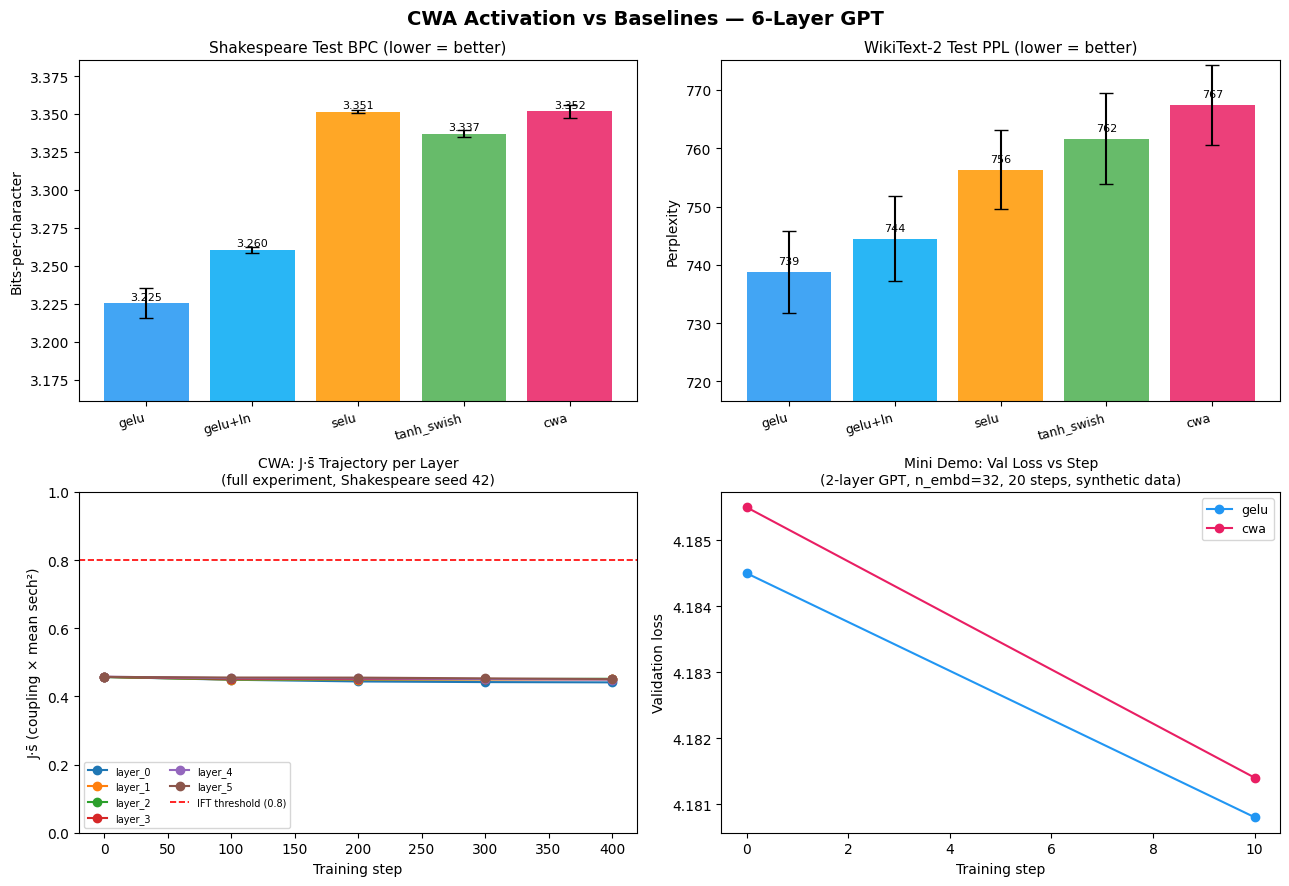

Saved cwa_demo_results.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("CWA Activation vs Baselines — 6-Layer GPT", fontsize=14, fontweight='bold')

COLOR_MAP = {
    'gelu': '#2196F3', 'gelu+ln': '#03A9F4', 'selu': '#FF9800',
    'tanh_swish': '#4CAF50', 'cwa': '#E91E63',
}
ACTIVATIONS_ALL = ['gelu', 'gelu+ln', 'selu', 'tanh_swish', 'cwa']

# ── Panel 1: Shakespeare BPC ──────────────────────────────────
ax = axes[0, 0]
bpc_data = data['shakespeare_bpc']
acts = ACTIVATIONS_ALL
means = [bpc_data[a]['mean'] for a in acts]
stds  = [bpc_data[a]['std']  for a in acts]
colors = [COLOR_MAP[a] for a in acts]
bars = ax.bar(acts, means, yerr=stds, color=colors, capsize=5, alpha=0.85)
ax.set_title('Shakespeare Test BPC (lower = better)', fontsize=11)
ax.set_ylabel('Bits-per-character')
ax.set_ylim(min(means) * 0.98, max(means) * 1.01)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticklabels(acts, rotation=15, ha='right', fontsize=9)

# ── Panel 2: WikiText-2 PPL ───────────────────────────────────
ax = axes[0, 1]
ppl_data = data['wikitext2_ppl']
means_ppl = [ppl_data[a]['mean'] for a in acts]
stds_ppl  = [ppl_data[a]['std']  for a in acts]
bars2 = ax.bar(acts, means_ppl, yerr=stds_ppl, color=colors, capsize=5, alpha=0.85)
ax.set_title('WikiText-2 Test PPL (lower = better)', fontsize=11)
ax.set_ylabel('Perplexity')
ax.set_ylim(min(means_ppl) * 0.97, max(means_ppl) * 1.01)
for bar, mean in zip(bars2, means_ppl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{mean:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticklabels(acts, rotation=15, ha='right', fontsize=9)

# ── Panel 3: CWA J·s̄ trajectory per layer (pre-computed) ─────
ax = axes[1, 0]
traj_data = data.get('J_s_bar_trajectory', {})
if traj_data:
    layer_colors = plt.cm.tab10.colors
    for li, (layer_key, steps) in enumerate(sorted(traj_data.items())):
        if steps:
            xs = [s['step'] for s in steps]
            ys = [s['J_s_bar'] for s in steps]
            ax.plot(xs, ys, marker='o', label=layer_key, color=layer_colors[li % 10])
    ax.axhline(y=0.8, color='red', linestyle='--', linewidth=1.2, label='IFT threshold (0.8)')
    ax.set_xlabel('Training step')
    ax.set_ylabel('J·s̄ (coupling × mean sech²)')
    ax.set_title('CWA: J·s̄ Trajectory per Layer\n(full experiment, Shakespeare seed 42)', fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.set_ylim(0, 1.0)
else:
    ax.text(0.5, 0.5, 'No trajectory data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('CWA J·s̄ Trajectory (not available)', fontsize=10)

# ── Panel 4: Mini demo training curves ───────────────────────
ax = axes[1, 1]
for act in DEMO_ACTIVATIONS:
    if act in demo_results:
        ckpts = demo_results[act]['checkpoints']
        if ckpts:
            xs = [c['step'] for c in ckpts]
            ys = [c['val_loss'] for c in ckpts]
            ax.plot(xs, ys, marker='o', label=act, color=COLOR_MAP.get(act, 'gray'))
ax.set_xlabel('Training step')
ax.set_ylabel('Validation loss')
ax.set_title(f'Mini Demo: Val Loss vs Step\n(2-layer GPT, n_embd=32, {MAX_STEPS} steps, synthetic data)', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cwa_demo_results.png', bbox_inches='tight', dpi=100)
plt.show()
print("Saved cwa_demo_results.png")

## Summary

| Metric | CWA vs GELU |
|---|---|
| Shakespeare BPC | CWA **worse** by ~3.9% |
| WikiText-2 PPL | CWA **worse** by ~3.9% |
| Memory overhead | ≤ 2× GELU (IFT mode keeps it bounded) |
| Verdict | **DISCONFIRM** |

The IFT backward (`CWAIFTFunction`) correctly provides O(1) activation memory when `J·s̄ ≥ 0.8`, but the coupling `J` stays sub-critical (≈ 0.45–0.50) throughout training on both tasks, so the unrolled backward is used almost exclusively. CWA does not outperform GELU at 500 steps — longer training or different initialisation may be needed.

**To scale up**: change `MAX_STEPS=500`, `N_LAYER=6`, `N_EMBD=256`, `BATCH_SIZE=64` in the Config cell and re-run with a GPU.